# Follicle counting

This notebook uses a helper script with DBSCAN to:

* Count putative individual B cell follicles in selected, annotated BANKSY domains
* Plot results in barplots and boxplots
* Save a summary of follicle counts across samples

Imports and setup:

In [14]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
print(PROJECT_ROOT)

/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics


In [15]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from pathlib import Path
import os
import hdbscan

### Define base names for samples of interest

In [19]:
basenames = [
    "IHOPE14_MedLN_BottomLeft",
    "IHOPE14_MedLN_BottomRight",
    "IHOPE14_MedLN_TopRight",
    "IHOPE14_mesLN",
    "IHOPE20_LN",
    "IHOPE20_Spleen",
    "IHOPE26_LN",
    "IHOPE26_Spleen",
    "IHOPE27_LN",
    "IHOPE27_Spleen",
    "IHOPE39_LN",
    "IHOPE39_MesLN_1",
    "IHOPE39_Spleen"
]

DATA_DIR = Path("../data/processed/anndata/NEW/debugged")
OUT_DIR = Path("../results/reports/follicle_counts/test")
OUT_DIR.mkdir(exist_ok=True, parents=True)

### Apply loop to all samples of interest


Processing IHOPE14_MedLN_BottomLeft
IHOPE14_MedLN_BottomLeft: 1066 B cells in follicle regions


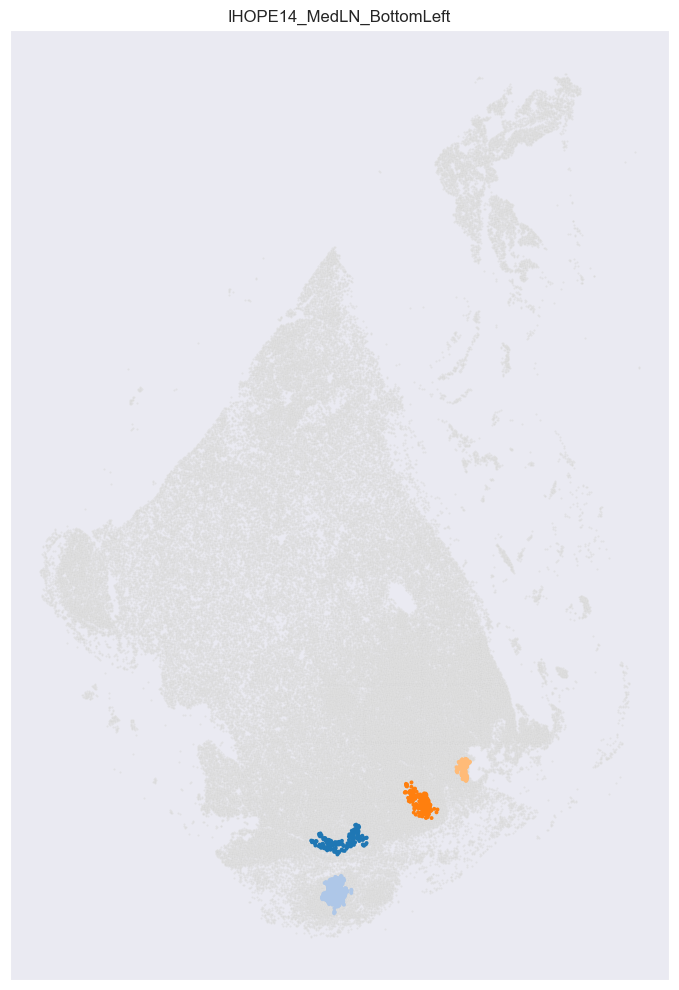

Plotted IHOPE14_MedLN_BottomLeft, saved as ../results/reports/follicle_counts/test/IHOPE14_MedLN_BottomLeft_follicles.png

Processing IHOPE14_MedLN_BottomRight
IHOPE14_MedLN_BottomRight: 22938 B cells in follicle regions


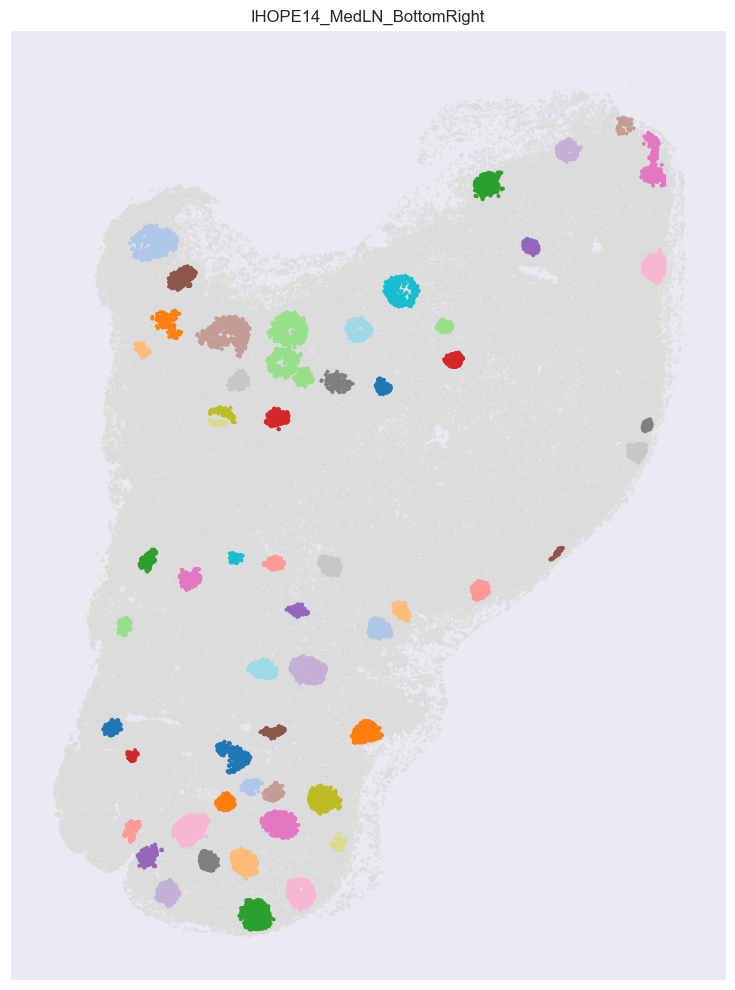

Plotted IHOPE14_MedLN_BottomRight, saved as ../results/reports/follicle_counts/test/IHOPE14_MedLN_BottomRight_follicles.png

Processing IHOPE14_MedLN_TopRight
IHOPE14_MedLN_TopRight: 28441 B cells in follicle regions


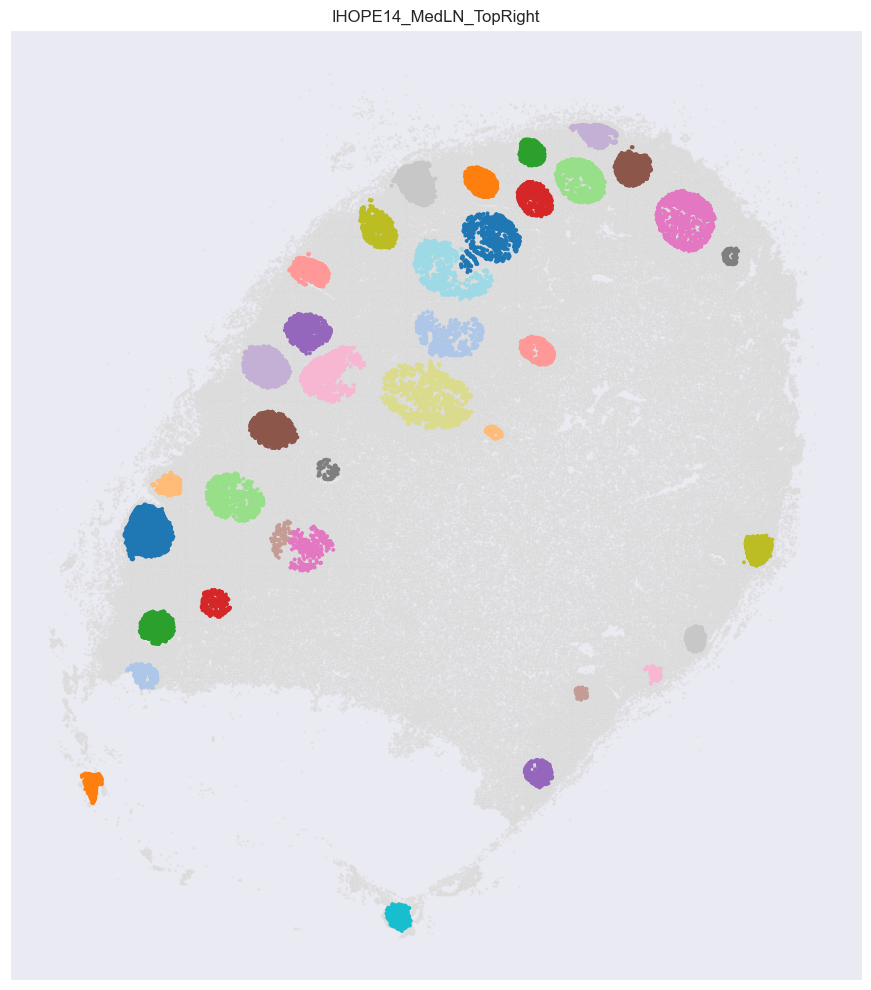

Plotted IHOPE14_MedLN_TopRight, saved as ../results/reports/follicle_counts/test/IHOPE14_MedLN_TopRight_follicles.png

Processing IHOPE14_mesLN
IHOPE14_mesLN: 11907 B cells in follicle regions


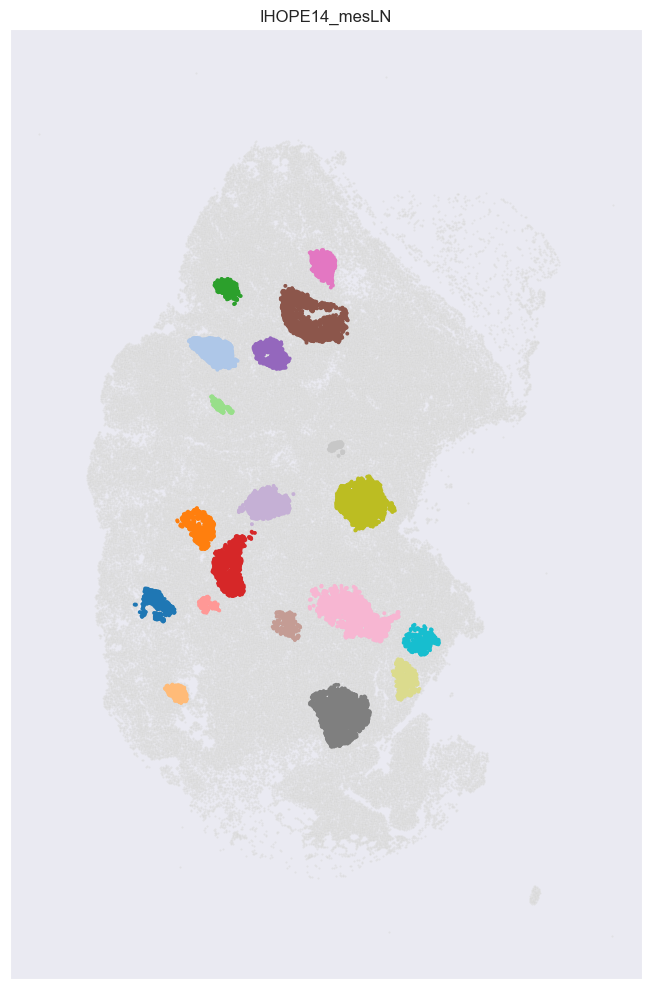

Plotted IHOPE14_mesLN, saved as ../results/reports/follicle_counts/test/IHOPE14_mesLN_follicles.png

Processing IHOPE20_LN
IHOPE20_LN: 9323 B cells in follicle regions


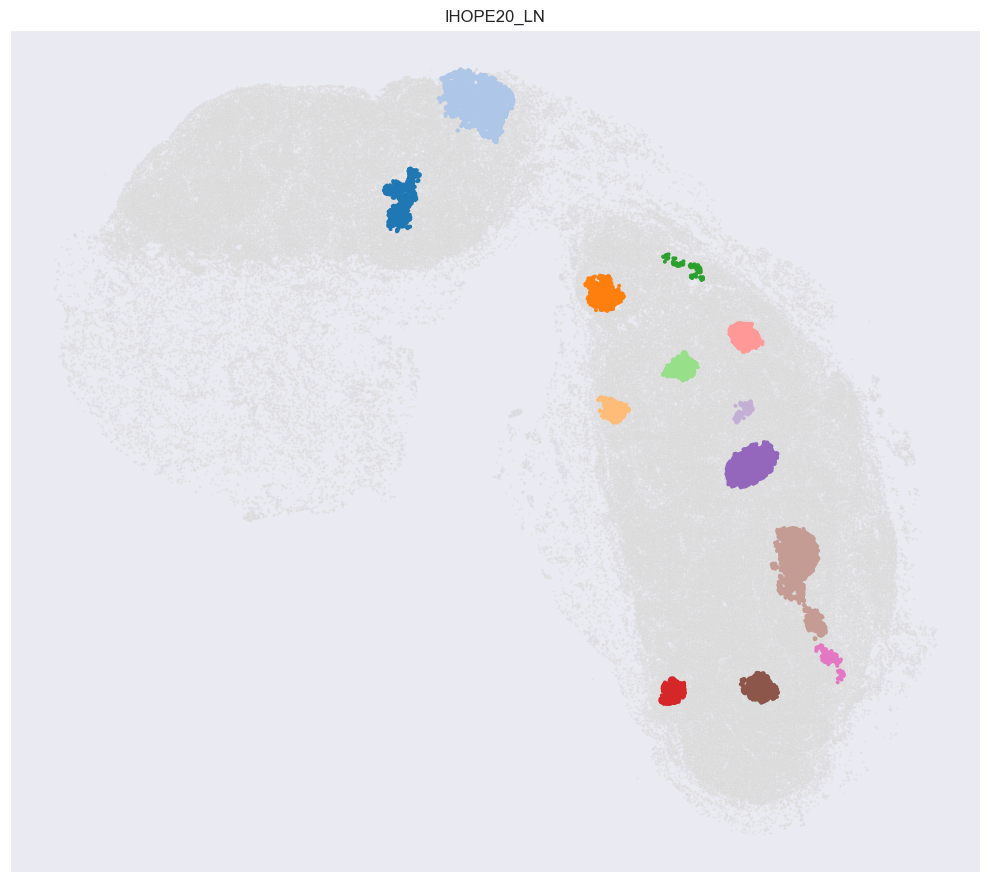

Plotted IHOPE20_LN, saved as ../results/reports/follicle_counts/test/IHOPE20_LN_follicles.png

Processing IHOPE20_Spleen
IHOPE20_Spleen: 23129 B cells in follicle regions


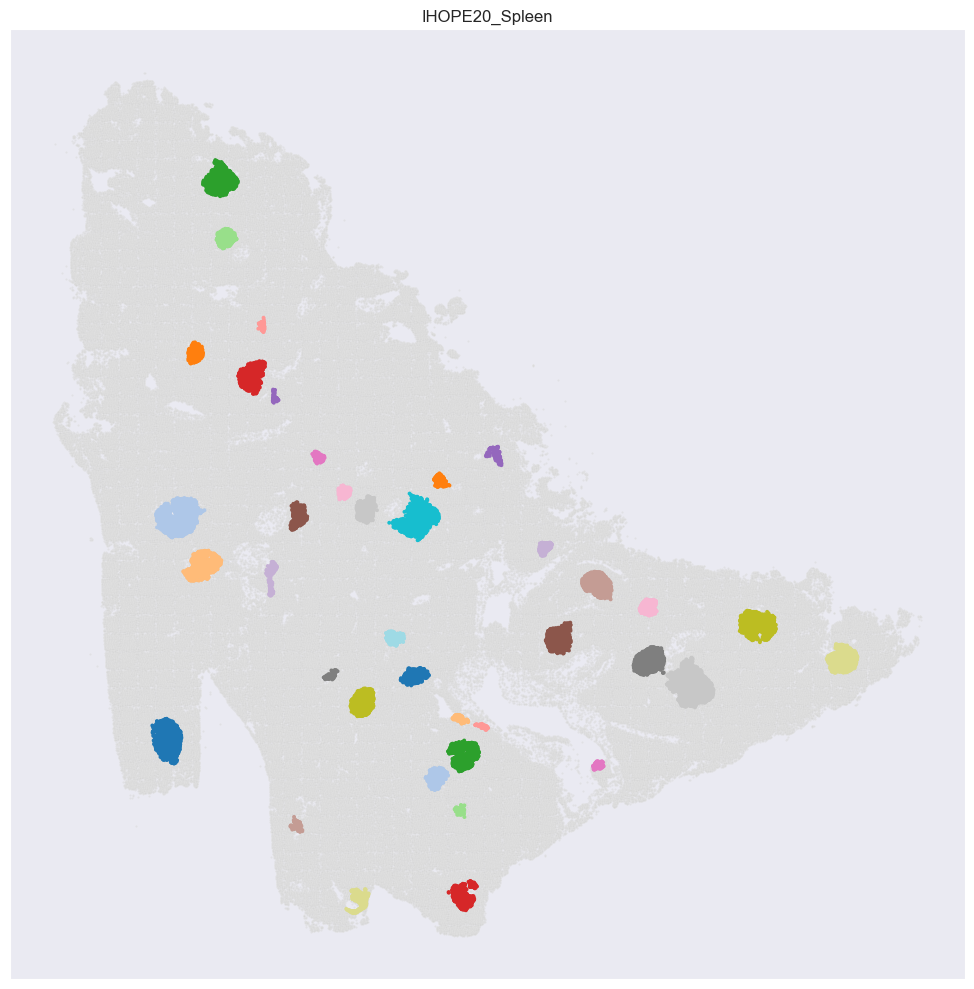

Plotted IHOPE20_Spleen, saved as ../results/reports/follicle_counts/test/IHOPE20_Spleen_follicles.png

Processing IHOPE26_LN
IHOPE26_LN: 14810 B cells in follicle regions


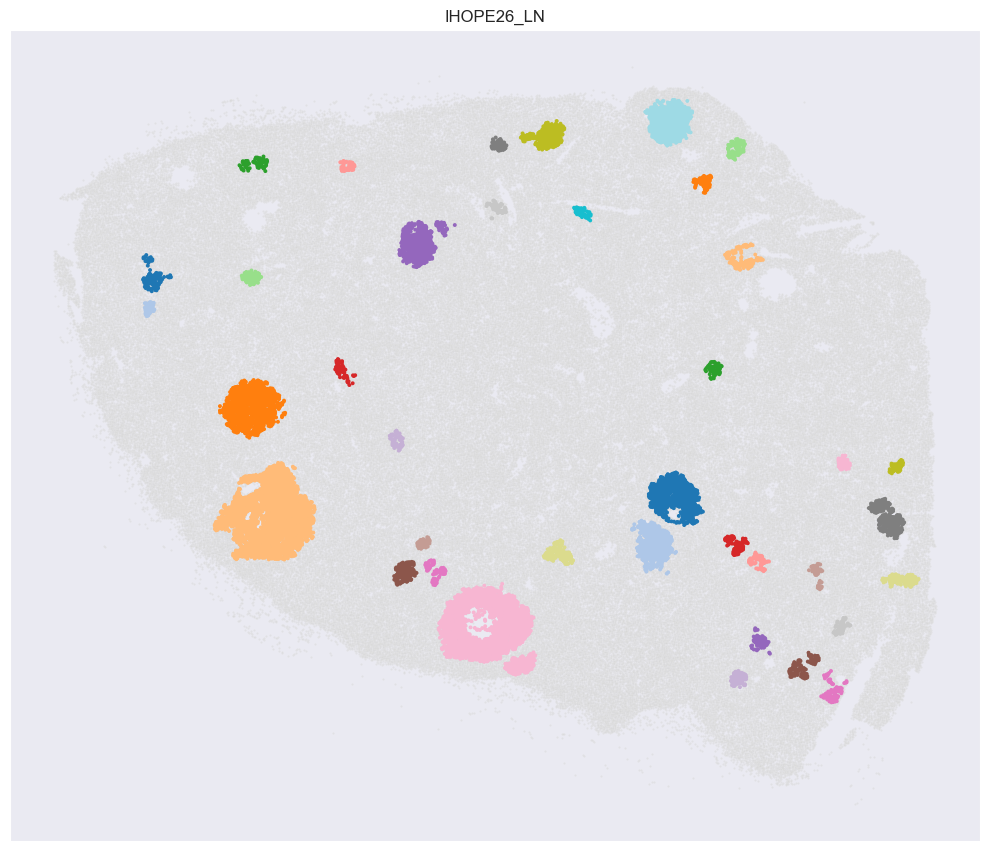

Plotted IHOPE26_LN, saved as ../results/reports/follicle_counts/test/IHOPE26_LN_follicles.png

Processing IHOPE26_Spleen
IHOPE26_Spleen: 6965 B cells in follicle regions


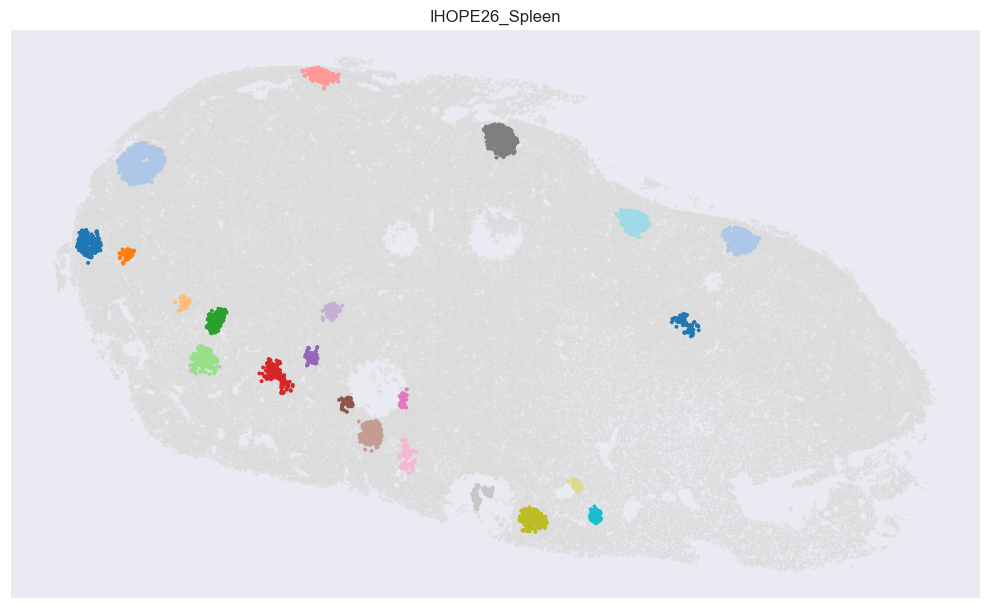

Plotted IHOPE26_Spleen, saved as ../results/reports/follicle_counts/test/IHOPE26_Spleen_follicles.png

Processing IHOPE27_LN
IHOPE27_LN: 11 B cells in follicle regions


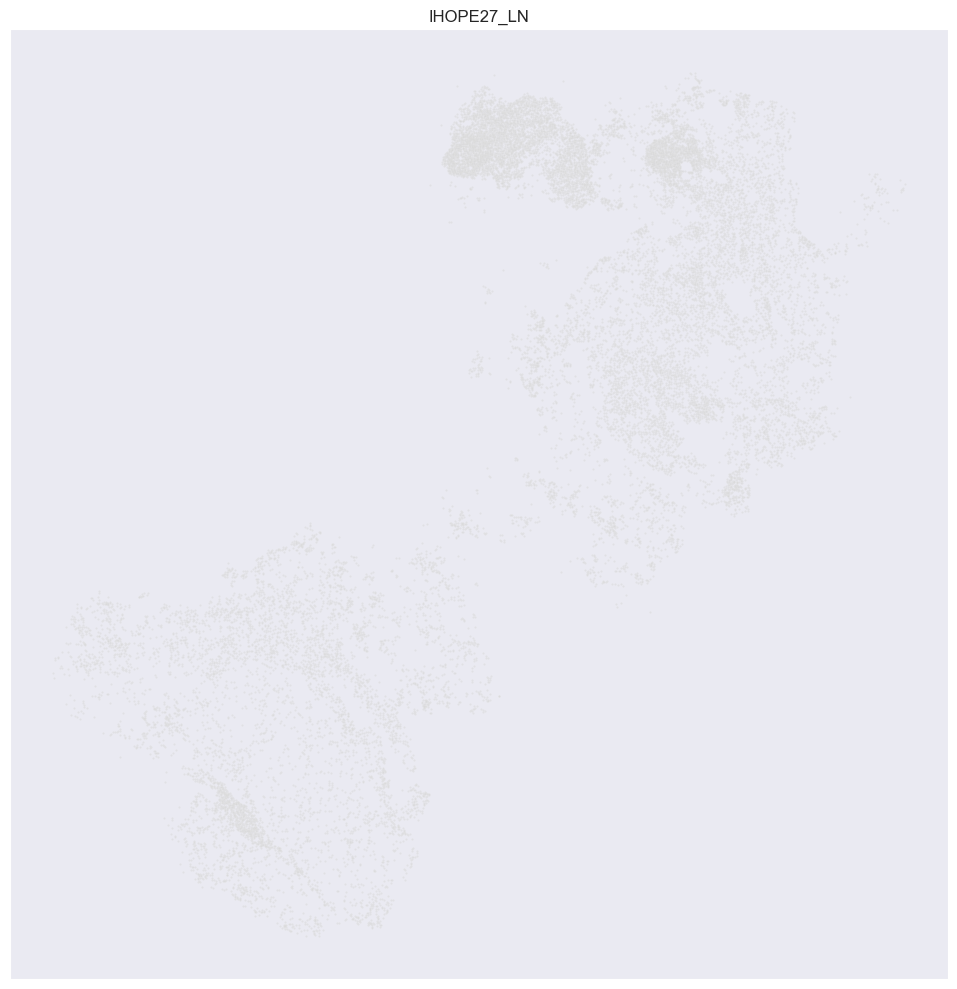

Plotted IHOPE27_LN, saved as ../results/reports/follicle_counts/test/IHOPE27_LN_follicles.png

Processing IHOPE27_Spleen
IHOPE27_Spleen: 6971 B cells in follicle regions


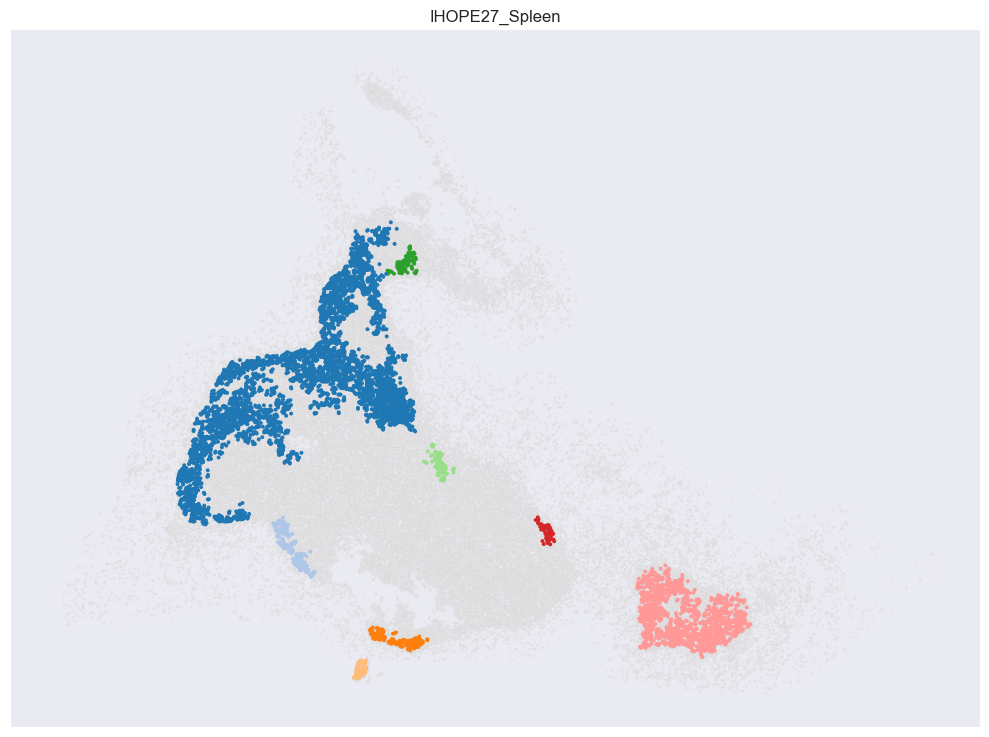

Plotted IHOPE27_Spleen, saved as ../results/reports/follicle_counts/test/IHOPE27_Spleen_follicles.png

Processing IHOPE39_LN
IHOPE39_LN: 8512 B cells in follicle regions


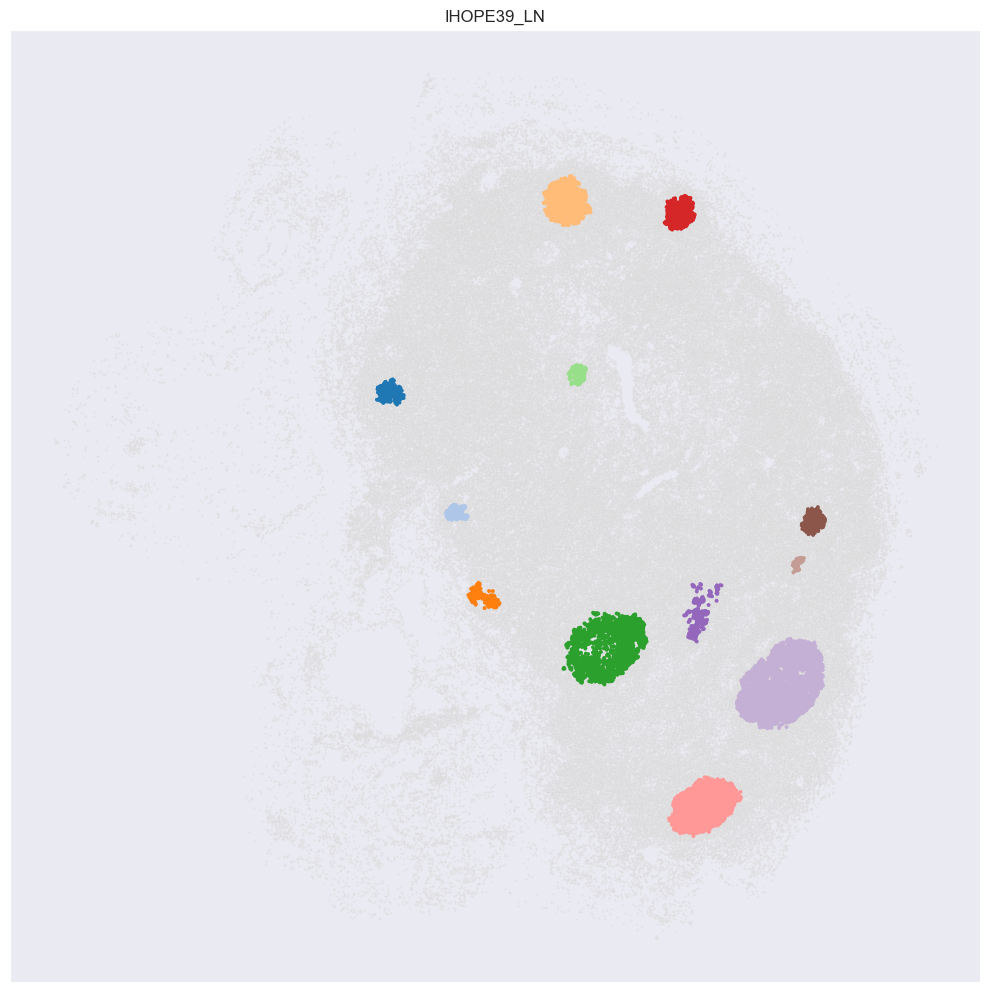

Plotted IHOPE39_LN, saved as ../results/reports/follicle_counts/test/IHOPE39_LN_follicles.png

Processing IHOPE39_MesLN_1
IHOPE39_MesLN_1: 0 B cells in follicle regions


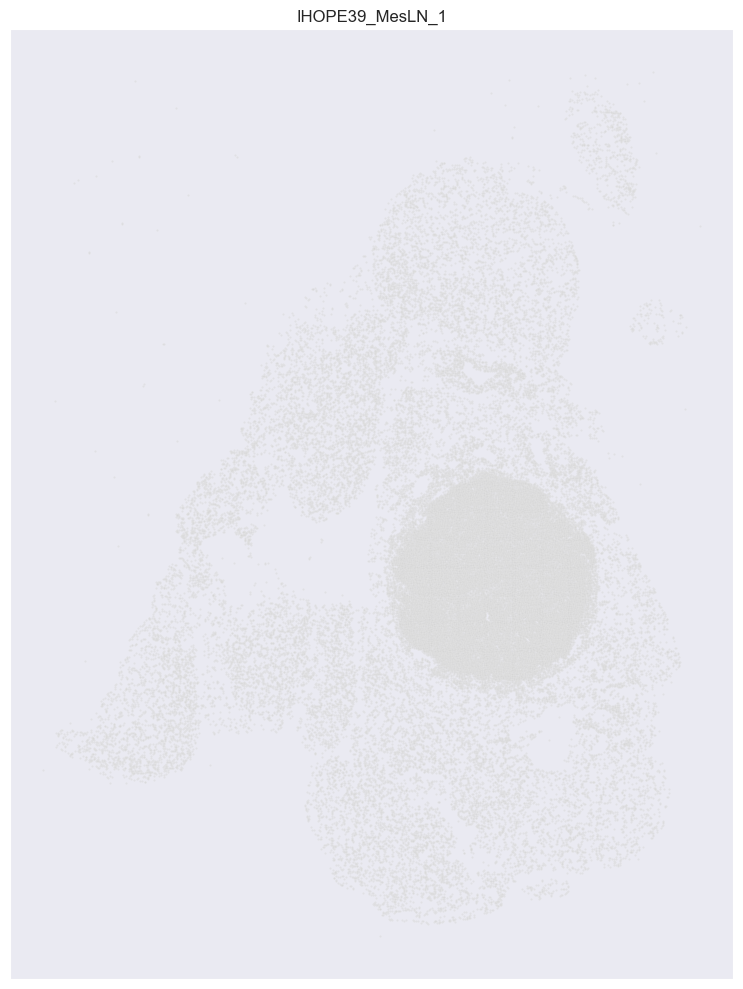

Plotted IHOPE39_MesLN_1, saved as ../results/reports/follicle_counts/test/IHOPE39_MesLN_1_follicles.png

Processing IHOPE39_Spleen
IHOPE39_Spleen: 10267 B cells in follicle regions


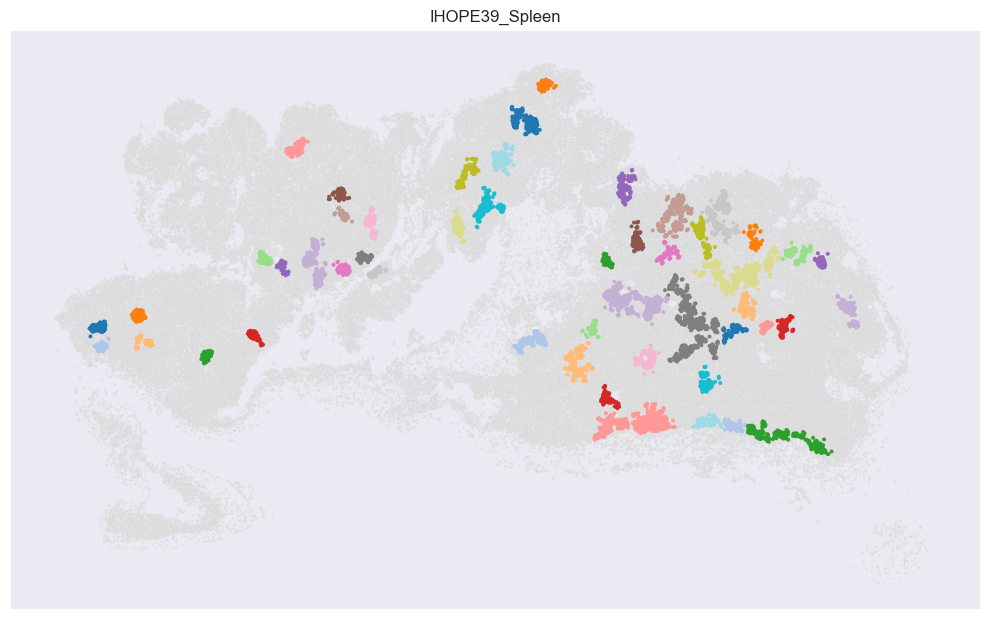

Plotted IHOPE39_Spleen, saved as ../results/reports/follicle_counts/test/IHOPE39_Spleen_follicles.png


In [20]:
import scripts.follicle_counting_helpers as fh

results = []

for basename in basenames:
    try:
        print(f"\nProcessing {basename}")

        filepath = (
            DATA_DIR /
            f"{basename}_celltypes_follicledomains.h5ad"
        )

        adata = sc.read_h5ad(filepath)

        mask = (
            (adata.obs["type_B"] == True) &
            (adata.obs["B_follicle"] == True)
        )

        print(f"{basename}: {mask.sum()} B cells in follicle regions")

        adata, n_follicles = fh.detect_follicles(adata)

        fh.plot_follicles(adata, basename, OUT_DIR)

        print(f"Plotted {basename}, saved as {OUT_DIR / f'{basename}_follicles.png'}")

        adata.write(
            OUT_DIR / f"{basename}_follicle_clustered.h5ad"
        )

        results.append({
            "sample": basename,
            "n_follicles": n_follicles,
            "n_candidate_Bcells": mask.sum(),
            "total_cells": adata.n_obs
        })

    except Exception as e:
        print(f"Failed on {basename}: {e}")

In [21]:
results_df = pd.DataFrame(results)

results_df = fh.normalize_follicle_counts(results_df)

results_df.to_csv(
    OUT_DIR / "follicle_counts_summary.csv",
    index=False
)

results_df

,sample,n_follicles,n_candidate_Bcells,total_cells,follicles_per_1000cells
0,IHOPE14_MedLN_BottomLeft,4,1066,112174,0.04
1,IHOPE14_MedLN_BottomRight,56,22938,399569,0.14
2,IHOPE14_MedLN_TopRight,37,28441,329482,0.11
3,IHOPE14_mesLN,19,11907,139439,0.14
4,IHOPE20_LN,13,9323,156354,0.08
5,IHOPE20_Spleen,38,23129,452411,0.08
6,IHOPE26_LN,38,14810,207039,0.18
7,IHOPE26_Spleen,22,6965,238378,0.09
8,IHOPE27_LN,0,11,20579,0.00
9,IHOPE27_Spleen,8,6971,59774,0.13


**Follicle counts per sample (ranked) – barplot**

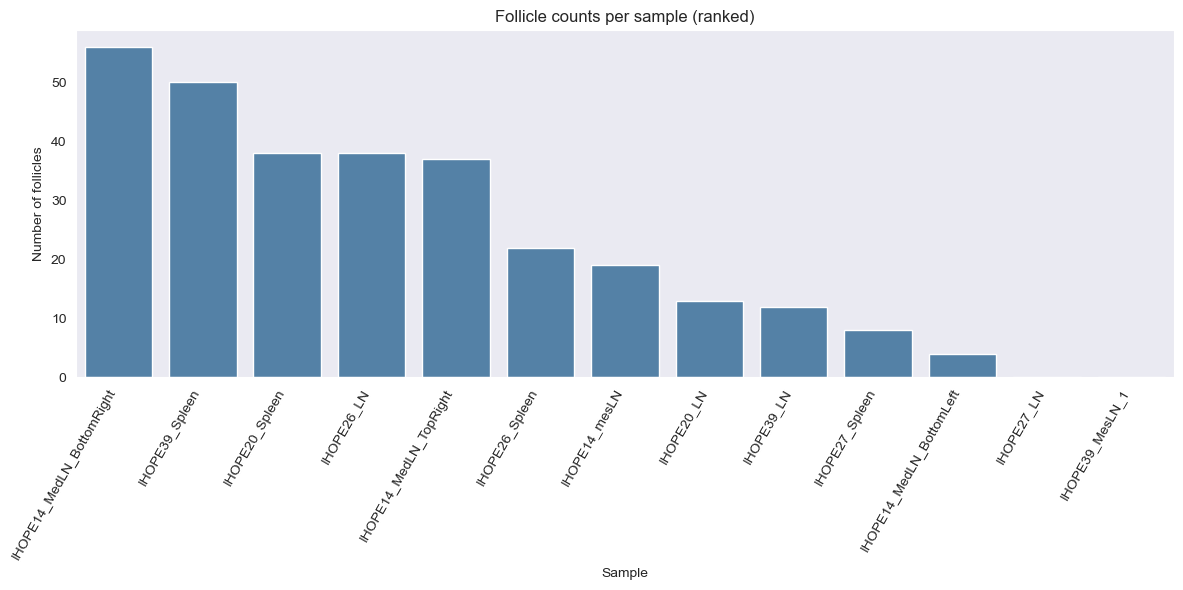

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

df_sorted = results_df.sort_values("n_follicles", ascending=False)

sns.barplot(
    data=df_sorted,
    x="sample",
    y="n_follicles",
    color="steelblue"
)

plt.xticks(rotation=60, ha="right")
plt.ylabel("Number of follicles")
plt.xlabel("Sample")
plt.title("Follicle counts per sample (ranked)")
plt.tight_layout()
plt.grid(False)


plt.savefig(
    OUT_DIR / "follicle_counts_ranked_barplot.png",
    dpi=300
)

plt.show()

**Normalized – follicle count per 1000 cells**

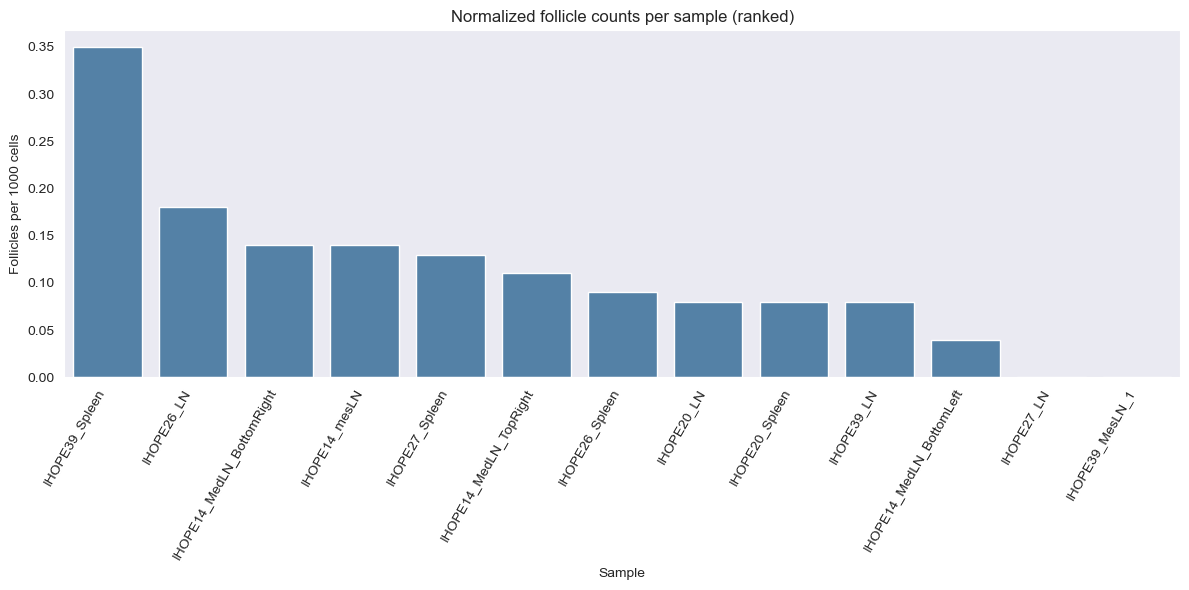

In [23]:
plt.figure(figsize=(12, 6))

df_sorted_norm = results_df.sort_values("follicles_per_1000cells", ascending=False)

sns.barplot(
    data=df_sorted_norm,
    x="sample",
    y="follicles_per_1000cells",
    color="steelblue"
)

plt.xticks(rotation=60, ha="right")
plt.ylabel("Follicles per 1000 cells")
plt.xlabel("Sample")
plt.title("Normalized follicle counts per sample (ranked)")
plt.tight_layout()
plt.grid(False)

plt.savefig(
    OUT_DIR / "follicle_counts_ranked_barplot_normalized.png",
    dpi=300
)

plt.show()

**Follicle counts per sample (custom order) – barplot**


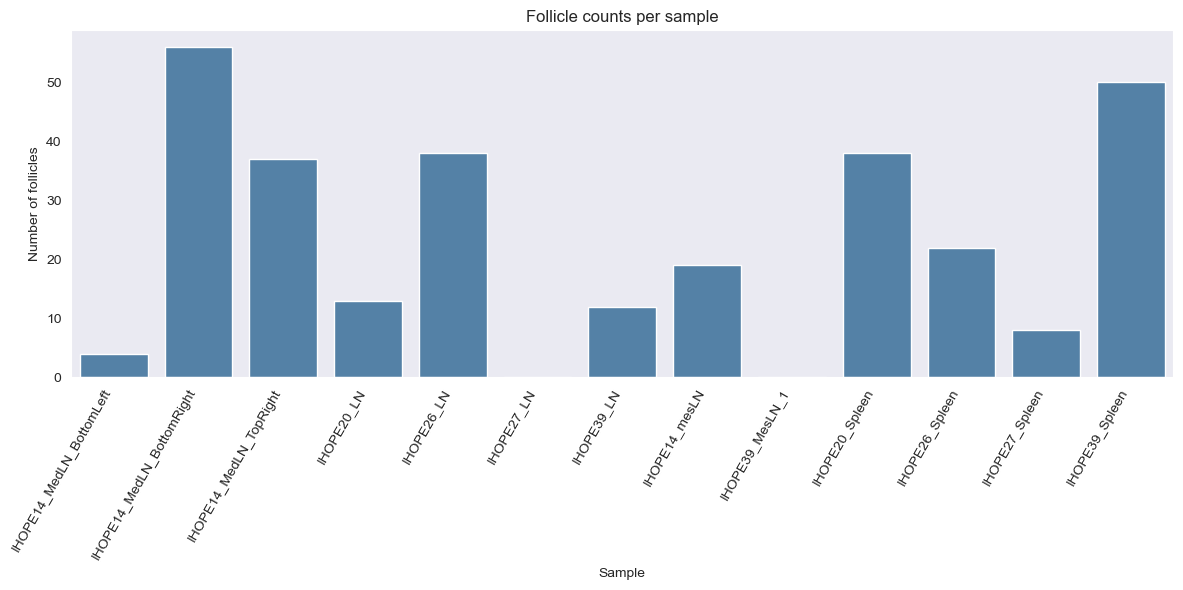

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Define order manually
custom_order = [
    "IHOPE14_MedLN_BottomLeft",
    "IHOPE14_MedLN_BottomRight",
    "IHOPE14_MedLN_TopRight",
    "IHOPE20_LN",
    "IHOPE26_LN",
    "IHOPE27_LN",
    "IHOPE39_LN",
    "IHOPE14_mesLN",
    "IHOPE39_MesLN_1",
    "IHOPE20_Spleen",
    "IHOPE26_Spleen",
    "IHOPE27_Spleen",
    "IHOPE39_Spleen"
]

sns.barplot(
    data=results_df,
    x="sample",
    y="n_follicles",
    order=custom_order,
    color="steelblue"
)

plt.xticks(rotation=60, ha="right")
plt.ylabel("Number of follicles")
plt.xlabel("Sample")
plt.title("Follicle counts per sample")
plt.tight_layout()
plt.grid(False)

plt.savefig(
    OUT_DIR / "follicle_counts_alphabetical_order_barplot.png",
    dpi=300
)

plt.show()

**Normalized**

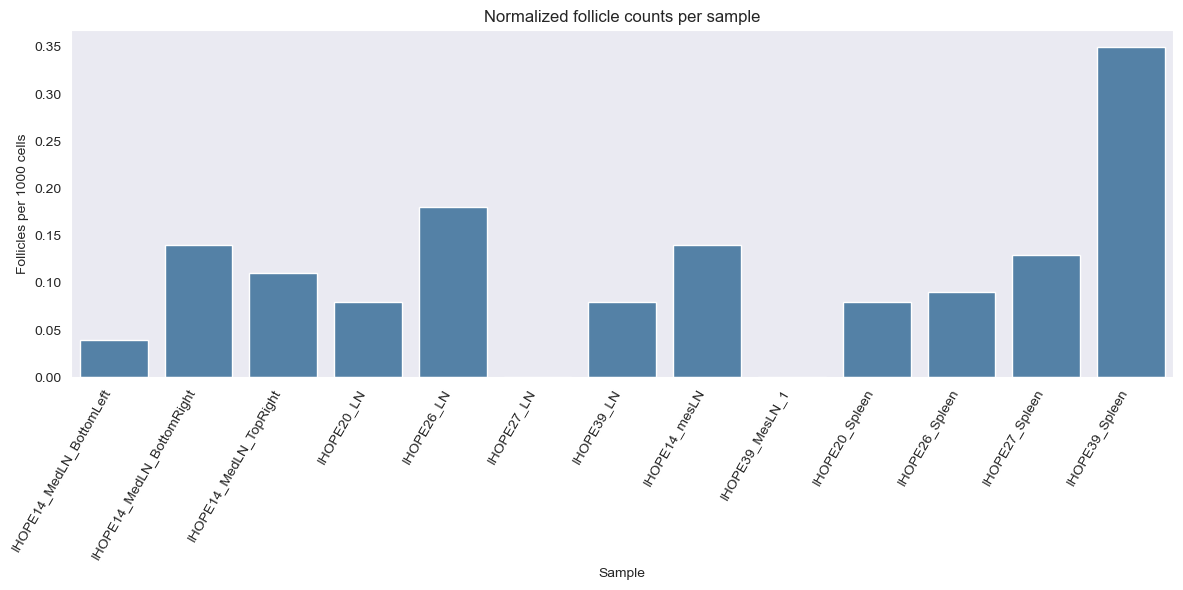

In [25]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="sample",
    y="follicles_per_1000cells",
    order=custom_order,
    color="steelblue"
)

plt.xticks(rotation=60, ha="right")
plt.ylabel("Follicles per 1000 cells")
plt.xlabel("Sample")
plt.title("Normalized follicle counts per sample")
plt.tight_layout()
plt.grid(False)

plt.savefig(
    OUT_DIR / "follicle_counts_alphabetical_order_barplot_normalized.png",
    dpi=300
)

plt.show()

**Follicle counts per sample (grouped by tissue manually) – boxplot**


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

tissue_map = {
    # MedLN
    "IHOPE14_MedLN_BottomLeft": "MedLN",
    "IHOPE14_MedLN_BottomRight": "MedLN",
    "IHOPE14_MedLN_TopRight": "MedLN",
    "IHOPE20_LN": "MedLN",
    "IHOPE26_LN": "MedLN",
    "IHOPE27_LN": "MedLN",
    "IHOPE39_LN": "MedLN",

    # MesLN
    "IHOPE14_mesLN": "MesLN",
    "IHOPE39_MesLN_1": "MesLN",

    # Spleen
    "IHOPE20_Spleen": "Spleen",
    "IHOPE26_Spleen": "Spleen",
    "IHOPE27_Spleen": "Spleen",
    "IHOPE39_Spleen": "Spleen"
}

results_df["tissue"] = results_df["sample"].map(tissue_map)

In [30]:
donor_map = {
    "IHOPE14_MedLN_BottomLeft": "IHOPE14",
    "IHOPE14_MedLN_BottomRight": "IHOPE14",
    "IHOPE14_MedLN_TopRight": "IHOPE14",
    "IHOPE20_LN": "IHOPE20",
    "IHOPE26_LN": "IHOPE26",
    "IHOPE27_LN": "IHOPE27",
    "IHOPE39_LN": "IHOPE39",

    "IHOPE14_mesLN": "IHOPE14",
    "IHOPE39_MesLN_1": "IHOPE39",

    "IHOPE20_Spleen": "IHOPE20",
    "IHOPE26_Spleen": "IHOPE26",
    "IHOPE27_Spleen": "IHOPE27",
    "IHOPE39_Spleen": "IHOPE39",
}

results_df["donor"] = results_df["sample"].map(donor_map)

donor_ids = sorted(results_df["donor"].unique())
donor_colors = dict(zip(donor_ids, sns.color_palette("colorblind", n_colors=len(donor_ids))))

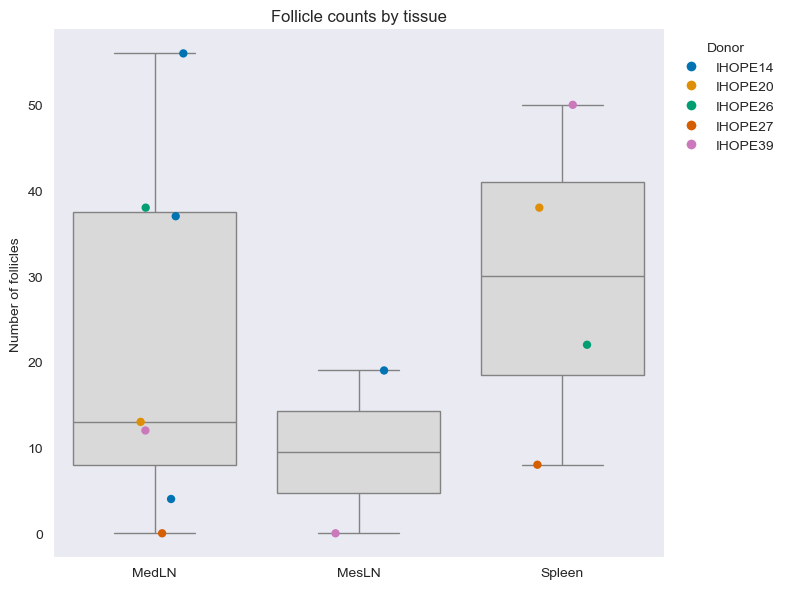

In [31]:
plt.figure(figsize=(8,6))

tissue_order = ["MedLN", "MesLN", "Spleen"]

sns.boxplot(
    data=results_df,
    x="tissue",
    y="n_follicles",
    order=tissue_order,
    color="0.85",
    showfliers=False
)

sns.stripplot(
    data=results_df,
    x="tissue",
    y="n_follicles",
    order=tissue_order,
    hue="donor",
    palette=donor_colors,
    legend=False,
    jitter=0.15,
    s=6
)

handles = [
    plt.Line2D([0], [0], marker="o", color="white", markerfacecolor=color,
               markersize=8, label=donor)
    for donor, color in donor_colors.items()
]
plt.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.0, 1.0),
           frameon=False, title="Donor")

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.ylabel("Number of follicles")
plt.title("Follicle counts by tissue")
plt.xlabel(None)
plt.tight_layout()
plt.grid(False)

plt.savefig(
    OUT_DIR / "follicle_counts_boxplot_tissue.png",
    dpi=300
)

plt.show()

**Normalized**

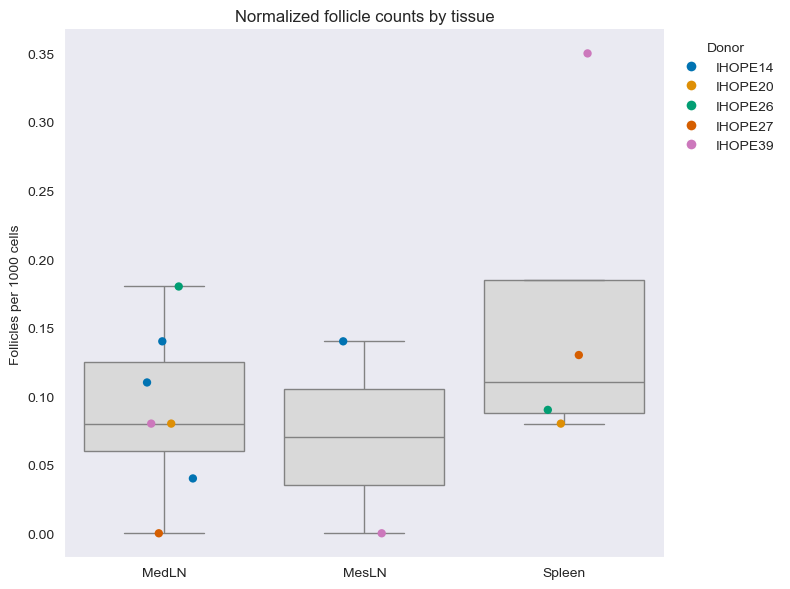

In [32]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=results_df,
    x="tissue",
    y="follicles_per_1000cells",
    order=tissue_order,
    color="0.85",
    showfliers=False
)

sns.stripplot(
    data=results_df,
    x="tissue",
    y="follicles_per_1000cells",
    order=tissue_order,
    hue="donor",
    palette=donor_colors,
    legend=False,
    jitter=0.15,
    s=6
)

handles = [
    plt.Line2D([0], [0], marker="o", color="white", markerfacecolor=color,
               markersize=8, label=donor)
    for donor, color in donor_colors.items()
]
plt.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.0, 1.0),
           frameon=False, title="Donor")

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.ylabel("Follicles per 1000 cells")
plt.title("Normalized follicle counts by tissue")
plt.xlabel(None)
plt.tight_layout()
plt.grid(False)

plt.savefig(
    OUT_DIR / "follicle_counts_boxplot_tissue_normalized.png",
    dpi=300
)

plt.show()

# Summary

Generate a full summary based on the cell type summary ("type" level) and the follicle counts.

In [29]:
follicle_df = pd.read_csv(
    OUT_DIR / "follicle_counts_summary.csv"
)

follicle_df.head()

,sample,n_follicles,n_candidate_Bcells,total_cells,follicles_per_1000cells
0,IHOPE14_MedLN_BottomLeft,4,1066,112174,0.04
1,IHOPE14_MedLN_BottomRight,56,22938,399569,0.14
2,IHOPE14_MedLN_TopRight,37,28441,329482,0.11
3,IHOPE14_mesLN,19,11907,139439,0.14
4,IHOPE20_LN,13,9323,156354,0.08


In [ ]:
from pathlib import Path
import pandas as pd

summary_dir = Path("../results/reports/NEW")

summary_files = list(
    summary_dir.glob("celltype_summary_*debugged_summary.csv")
)

summary_files

In [ ]:
all_rows = []

for file in summary_files:

    df = pd.read_csv(file)

    sample_name = (
        file.stem
        .replace("celltype_summary_", "")
        .replace("_debugged_summary", "")
    )

    type_df = df[df["level"] == "type"]

    row = {"sample": sample_name}

    if len(type_df) > 0:
        row["total_cells"] = type_df["total_cells"].iloc[0]

    for _, r in type_df.iterrows():
        ct = r["cell_type"]

        row[f"{ct}_count"] = r["n_cells"]
        row[f"{ct}_pct"] = r["pct_total"]

    all_rows.append(row)

celltype_wide = pd.DataFrame(all_rows)

celltype_wide.head()

In [ ]:
final_report = follicle_df.merge(
    celltype_wide,
    on="sample",
    how="left"
)

final_report

In [ ]:
final_report.to_csv(
    OUT_DIR / "follicle_celltype_report.csv",
    index=False
)

final_report